# 神经网络 NumPy 实现

🎯 学习目标：从零实现神经网络的核心机制

**本节内容**：
- 1.6 完整神经元的 NumPy 实现（前向+反向传播）
- 1.7 多层神经网络的鸢尾花分类实现

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体和显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

print("✅ 导入完成！")

✅ 导入完成！


---
## 1.6 NumPy 从零实现神经元

### 1.6.1 激活函数及其导数

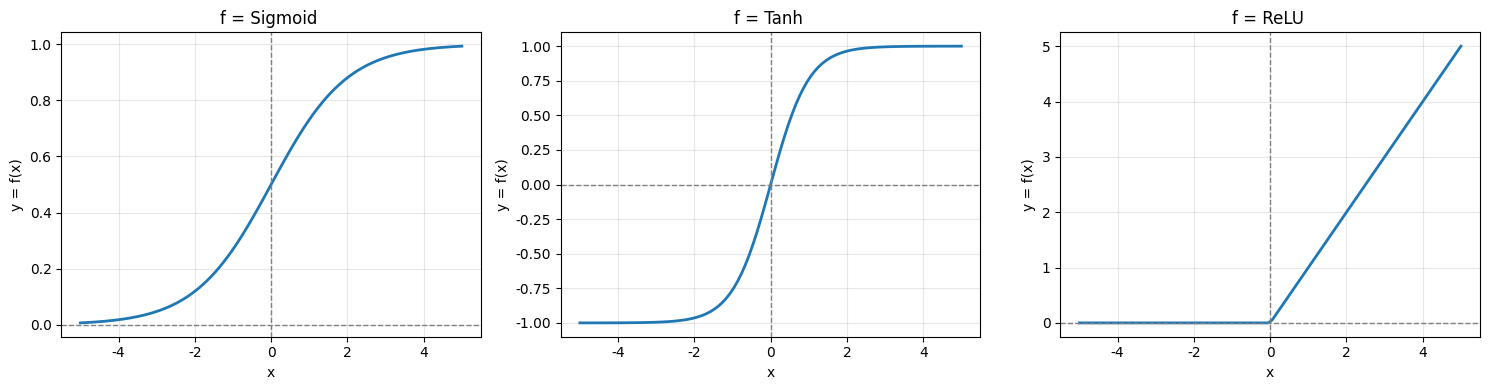

📊 激活函数可视化完成！


In [3]:
class ActivationFunctions:
    """激活函数及其导数实现"""

    @staticmethod
    def sigmoid(z):
        """Sigmoid函数及其导数"""
        a = 1 / (1 + np.exp(-z))
        # sigmoid的导数：a * (1 - a)
        da = a * (1 - a)
        return a, da

    @staticmethod
    def tanh(z):
        """Tanh函数及其导数"""
        a = np.tanh(z)
        # tanh的导数：1 - a²
        da = 1 - a**2
        return a, da

    @staticmethod
    def relu(z):
        """ReLU函数及其导数"""
        a = np.maximum(0, z)
        # ReLU的导数：z > 0时为1，否则为0
        da = (z > 0).astype(float)
        return a, da

    @staticmethod
    def softmax(z):
        """Softmax函数（用于多分类）"""
        # 计算指数值
        exp_z = np.exp(z)
        # 计算归一化因子
        sum_exp_z = exp_z.sum()
        # 计算Softmax输出
        a = exp_z / sum_exp_z
        # a的导数：a * (1 - a) * (1 - a)
        da = a * (1 - a) * (1 - a)
        return a, da


# 测试激活函数
z_test = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
activations = [('sigmoid', 'Sigmoid'), ('tanh', 'Tanh'), ('relu', 'ReLU')]

for ax, (name, title) in zip(axes, activations):
    if name == 'sigmoid':
        a, _ = ActivationFunctions.sigmoid(z_test)
    elif name == 'tanh':
        a, _ = ActivationFunctions.tanh(z_test)
    else:  # relu
        a, _ = ActivationFunctions.relu(z_test)

    ax.plot(z_test, a, linewidth=2)
    ax.set_title(f'f = {title} ')
    ax.set_xlabel('x')
    ax.set_ylabel('y = f(x)')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

print("📊 激活函数可视化完成！")

### 1.6.2 完整神经元实现（含反向传播）

In [4]:
class Neuron:
    """单个神经元：支持前向传播和反向传播"""

    def __init__(self, n_inputs: int, activation: str = 'relu'):
        """
        初始化神经元

        参数:
            n_inputs: 输入特征数量
            activation: 激活函数类型 ('sigmoid', 'tanh', 'relu')
        """
        # 随机初始化权重和偏置（小随机数有助于训练）
        self.w = np.random.randn(n_inputs) * 0.1
        self.b = np.random.randn() * 0.1
        self.activation_name = activation

        # 缓存前向传播的中间结果（反向传播时需要）
        self.z_cache = None
        self.a_cache = None
        self.x_cache = None

    def forward(self, x):
        """前向传播

        参数:
            x: 输入向量，形状 (n_inputs,)

        返回:
            a: 神经元输出（标量）
        """
        # 缓存输入
        self.x_cache = x.copy()

        # 线性变换：z = w·x + b
        self.z_cache = np.dot(self.w, x) + self.b

        # 激活函数：a = σ(z)
        if self.activation_name == 'sigmoid':
            self.a_cache, _ = ActivationFunctions.sigmoid(self.z_cache)
        elif self.activation_name == 'tanh':
            self.a_cache, _ = ActivationFunctions.tanh(self.z_cache)
        elif self.activation_name == 'relu':
            self.a_cache, _ = ActivationFunctions.relu(self.z_cache)
        else:
            self.a_cache = self.z_cache  # 无激活函数

        return self.a_cache

    def backward(self, dL_da, learning_rate=0.01):
        """反向传播：计算梯度并更新参数

        参数:
            dL_da: 损失对输出的梯度（标量）
            learning_rate: 学习率

        返回:
            dL_dx: 损失对输入的梯度，形状 (n_inputs,)
        """
        # 1. 计算激活函数的导数：da/dz
        if self.activation_name == 'sigmoid':
            _, da_dz = ActivationFunctions.sigmoid(self.z_cache)
        elif self.activation_name == 'tanh':
            _, da_dz = ActivationFunctions.tanh(self.z_cache)
        elif self.activation_name == 'relu':
            _, da_dz = ActivationFunctions.relu(self.z_cache)
        else:
            da_dz = 1.0  # 无激活函数时导数为1

        # 2. 链式法则：dL/dz = dL/da * da/dz
        dL_dz = dL_da * da_dz

        # 3. 计算参数梯度：
        # dL/dw = dL/dz * dz/dw = dL/dz * x
        dL_dw = dL_dz * self.x_cache
        # dL/db = dL/dz * dz/db = dL/dz * 1
        dL_db = dL_dz

        # 4. 更新参数（梯度下降）
        self.w -= learning_rate * dL_dw
        self.b -= learning_rate * dL_db

        # 5. 计算输入梯度（用于反向传播到上一层）：
        # dL/dx = dL/dz * dz/dx = dL/dz * w
        dL_dx = dL_dz * self.w

        return dL_dx


# 测试神经元
print("=" * 50)
print("创建一个3输入的ReLU神经元：")
print("=" * 50)
neuron = Neuron(n_inputs=3, activation='relu')

x = np.array([1.0, 2.0, 3.0])
print(f"\n输入 x: {x}")
print(f"初始权重 w: {neuron.w}")
print(f"初始偏置 b: {neuron.b:.4f}")

# 前向传播
output = neuron.forward(x)
print(f"前向传播输出: {output:.4f}")
print(f"缓存的 z: {neuron.z_cache:.4f}")

# 假设损失梯度（标量）
dL_da = 0.5  # 损失对输出的梯度
print(f"损失梯度 dL/da: {dL_da}")

# 反向传播
dL_dx = neuron.backward(dL_da, learning_rate=0.1)
print(f"反向传播后：")
print(f"更新后权重 w: {neuron.w}")
print(f"更新后偏置 b: {neuron.b:.4f}")
print(f"输入梯度 dL/dx: {dL_dx}")

# 验证梯度计算
print(f"梯度验证：")
print(f"权重变化量: {0.1 * dL_da * (1 if output > 0 else 0) * x}")  # ReLU导数

创建一个3输入的ReLU神经元：

输入 x: [1. 2. 3.]
初始权重 w: [-0.1201144  -0.08570744  0.07869209]
初始偏置 b: 0.0224
前向传播输出: 0.0000
缓存的 z: -0.0331
损失梯度 dL/da: 0.5
反向传播后：
更新后权重 w: [-0.1201144  -0.08570744  0.07869209]
更新后偏置 b: 0.0224
输入梯度 dL/dx: [-0. -0.  0.]
梯度验证：
权重变化量: [0. 0. 0.]


---
## 1.7 多层神经网络实现

### 1.7.1 神经网络类实现

In [5]:
class NeuralNetwork:
    """多层神经网络实现（基于 NumPy）"""

    def __init__(self, layer_sizes, activations):
        """
        初始化神经网络

        参数:
            layer_sizes: 各层神经元数量，如 [4, 64, 32, 3]
            activations: 各层激活函数，如 ['relu', 'relu', 'softmax']
        """
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.n_layers = len(layer_sizes) - 1

        # 初始化权重和偏置
        self.weights = []
        self.biases = []

        for i in range(self.n_layers):
            n_inputs = layer_sizes[i]
            n_outputs = layer_sizes[i + 1]

            # Xavier初始化
            scale = np.sqrt(2.0 / n_inputs)
            self.weights.append(np.random.randn(n_outputs, n_inputs) * scale)
            self.biases.append(np.zeros(n_outputs))

        # 缓存前向传播结果
        self.z_cache = []
        self.a_cache = []

    def forward(self, x):
        """前向传播

        参数:
            x: 输入数据，形状 (n_samples, n_inputs)

        返回:
            y: 网络输出，形状 (n_samples, n_outputs)
        """
        self.a_cache = [x]
        self.z_cache = []

        for i in range(self.n_layers):
            # 线性变换：z = Wx + b
            z = np.dot(self.a_cache[-1], self.weights[i].T) + self.biases[i]
            self.z_cache.append(z)

            # 激活函数
            if self.activations[i] == 'softmax':
                a = self._softmax(z)
            elif self.activations[i] == 'sigmoid':
                a, _ = ActivationFunctions.sigmoid(z)
            elif self.activations[i] == 'tanh':
                a, _ = ActivationFunctions.tanh(z)
            elif self.activations[i] == 'relu':
                a, _ = ActivationFunctions.relu(z)
            else:
                a = z  # 线性激活

            self.a_cache.append(a)

        return self.a_cache[-1]

    def _softmax(self, z):
        """Softmax函数（数值稳定版本）"""
        z_stable = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_stable)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def backward(self, y_true, learning_rate=0.01):
        """反向传播：计算梯度并更新参数

        参数:
            y_true: 真实标签，形状 (n_samples, n_outputs) (one-hot编码)
            learning_rate: 学习率
        """
        # 获取预测值
        y_pred = self.a_cache[-1]
        n_samples = y_true.shape[0]

        # 初始化梯度：对于 Softmax + 交叉熵，梯度是 y_pred - y_true
        if self.activations[-1] == 'softmax':
            dL_da = (y_pred - y_true) / n_samples
        else:
            # 对于其他损失函数，需要单独计算
            dL_da = y_pred - y_true  # 假设使用 MSE

        # 从最后一层往前反向传播
        for i in reversed(range(self.n_layers)):
            z = self.z_cache[i]
            a_prev = self.a_cache[i]

            # 计算 dL/dz
            if i == self.n_layers - 1 and self.activations[i] == 'softmax':
                # Softmax + 交叉熵的特殊情况：梯度已经简化
                dL_dz = dL_da
            else:
                # 计算激活函数导数
                if self.activations[i] == 'sigmoid':
                    _, da_dz = ActivationFunctions.sigmoid(z)
                elif self.activations[i] == 'tanh':
                    _, da_dz = ActivationFunctions.tanh(z)
                elif self.activations[i] == 'relu':
                    _, da_dz = ActivationFunctions.relu(z)
                else:
                    da_dz = np.ones_like(z)

                # 链式法则：dL/dz = dL/da * da/dz
                dL_dz = dL_da * da_dz

            # 计算参数梯度
            dL_dW = np.dot(dL_dz.T, a_prev)
            dL_db = np.sum(dL_dz, axis=0)

            # 更新参数
            self.weights[i] -= learning_rate * dL_dW
            self.biases[i] -= learning_rate * dL_db

            # 计算传递给前一层的梯度
            if i > 0:  # 不需要计算输入层的梯度
                dL_da = np.dot(dL_dz, self.weights[i])

    def cross_entropy_loss(self, y_true, y_pred):
        """交叉熵损失函数

        参数:
            y_true: 真实标签 (one-hot)，形状 (n_samples, n_classes)
            y_pred: 预测概率，形状 (n_samples, n_classes)

        返回:
            loss: 平均交叉熵损失
        """
        # 避免 log(0)
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)

        # 交叉熵：-sum(y_true * log(y_pred))
        loss = -np.sum(y_true * np.log(y_pred)) / y_true.shape[0]
        return loss

    def predict(self, x):
        """预测类别

        参数:
            x: 输入数据，形状 (n_samples, n_inputs)

        返回:
            predictions: 预测的类别索引，形状 (n_samples,)
        """
        y_pred = self.forward(x)
        return np.argmax(y_pred, axis=1)

    def summary(self):
        """打印网络结构信息"""
        print("=" * 60)
        print("神经网络结构")
        print("=" * 60)
        print(f"网络结构: {' → '.join(map(str, self.layer_sizes))}")
        print(f"激活函数: {' → '.join(self.activations)}")

        total_params = 0
        for i, (w, b) in enumerate(zip(self.weights, self.biases)):
            layer_params = w.size + b.size
            total_params += layer_params
            print(f"第 {i+1} 层: {w.shape} + {b.shape} = {layer_params:,} 参数")

        print(f"总参数量: {total_params:,}")
        print("=" * 60)


# 测试代码
print("创建一个 4→64→32→3 的神经网络：\n")
nn = NeuralNetwork(
    layer_sizes=[4, 64, 32, 3],
    activations=['relu', 'relu', 'softmax']
)

nn.summary()

# 生成测试数据
x_test = np.random.randn(5, 4)  # 5个样本，4个特征
y_test = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
    [1, 0, 0],
    [0, 1, 0]
])  # one-hot编码的标签

print("前向传播测试：")
y_pred = nn.forward(x_test)
print(f"输入形状: {x_test.shape}")
print(f"输出形状: {y_pred.shape}")
print(f"输出（前3个样本）:\n{y_pred[:3]}")
print(f"每行和: {y_pred.sum(axis=1)}")  # 应该都是1

print("损失计算：")
loss = nn.cross_entropy_loss(y_test, y_pred)
print(f"交叉熵损失: {loss:.4f}")

print("反向传播测试：")
nn.backward(y_test, learning_rate=0.01)
print("参数已更新！")

print("预测测试：")
predictions = nn.predict(x_test)
print(f"预测类别: {predictions}")
print(f"真实类别: {np.argmax(y_test, axis=1)}")

创建一个 4→64→32→3 的神经网络：

神经网络结构
网络结构: 4 → 64 → 32 → 3
激活函数: relu → relu → softmax
第 1 层: (64, 4) + (64,) = 320 参数
第 2 层: (32, 64) + (32,) = 2,080 参数
第 3 层: (3, 32) + (3,) = 99 参数
总参数量: 2,499
前向传播测试：
输入形状: (5, 4)
输出形状: (5, 3)
输出（前3个样本）:
[[0.81241839 0.04869272 0.13888888]
 [0.90538439 0.02331397 0.07130164]
 [0.84136079 0.05475308 0.10388613]]
每行和: [1. 1. 1. 1. 1.]
损失计算：
交叉熵损失: 2.1631
反向传播测试：
参数已更新！
预测测试：
预测类别: [0 0 0 0 0]
真实类别: [0 1 2 0 1]


### 1.7.2 人工生成模拟数据

In [14]:
def generate_dataset(n_samples=150, n_features=4, n_classes=3, random_seed=42):
    """生成模拟数据（类似鸢尾花数据集）

    参数:
        n_samples: 样本数量
        n_features: 特征数量
        n_classes: 类别数量
        random_seed: 随机种子

    返回:
        X: 特征矩阵 (n_samples, n_features)
        y: 标签向量 (n_samples,)，值为0,1,2
    """
    np.random.seed(random_seed)

    # 生成每个类别的数据中心
    class_centers = np.random.randn(n_classes, n_features) * 2 + 3

    X = []
    y = []

    # 为每个类别生成样本
    for class_idx in range(n_classes):
        n_samples_class = n_samples // n_classes

        # 在中心点周围生成正态分布的样本
        class_samples = np.random.randn(
            n_samples_class, n_features) + class_centers[class_idx]

        X.append(class_samples)
        y.extend([class_idx] * n_samples_class)

    X = np.vstack(X)
    y = np.array(y)

    # 打乱数据顺序
    indices = np.random.permutation(len(X))
    X = X[indices]
    y = y[indices]

    return X, y


# 生成数据
X, y = generate_dataset(n_samples=150, n_features=4, n_classes=3)

print(f"数据形状: X={X.shape}, y={y.shape}")
print(f"各类样本数: {np.bincount(y)}")
print(f"特征范围: [{X.min():.2f}, {X.max():.2f}]")

# 数据标准化
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_normalized = (X - X_mean) / X_std

print(f"\n标准化后: 均值≈0, 标准差≈1")
print(f"标准化后均值: {X_normalized.mean(axis=0)}")
print(f"标准化后标准差: {X_normalized.std(axis=0)}")

数据形状: X=(150, 4), y=(150,)
各类样本数: [50 50 50]
特征范围: [-0.41, 8.77]

标准化后: 均值≈0, 标准差≈1
标准化后均值: [ 6.18764299e-16 -4.34467277e-16 -1.14575016e-15  8.21565038e-17]
标准化后标准差: [1. 1. 1. 1.]


### 1.7.3 数据分割

In [15]:
def train_test_split(X, y, test_size=0.2, random_state=42):
    """将数据分为训练集和测试集"""
    n_samples = len(X)
    n_train = int(n_samples * (1 - test_size))

    indices = np.random.permutation(n_samples)
    train_indices = indices[:n_train]
    test_indices = indices[n_train:]

    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]


# 分割数据
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y)

print(f"训练集: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"测试集: X_test={X_test.shape}, y_test={y_test.shape}")
print(f"\n训练集各类样本数: {np.bincount(y_train)}")
print(f"测试集各类样本数: {np.bincount(y_test)}")

训练集: X_train=(120, 4), y_train=(120,)
测试集: X_test=(30, 4), y_test=(30,)

训练集各类样本数: [38 41 41]
测试集各类样本数: [12  9  9]


### 1.7.4 训练函数

In [16]:
def train_network(network, X_train, y_train, X_test, y_test,
                  epochs=100, batch_size=32, learning_rate=0.01):
    """
    训练神经网络

    参数:
        network: 神经网络实例
        X_train, y_train: 训练数据
        X_test, y_test: 测试数据
        epochs: 训练轮数
        batch_size: 批次大小
        learning_rate: 学习率

    返回:
        history: 训练历史记录
    """
    n_samples = len(X_train)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'epoch': []
    }

    # ✅ 改进的 one-hot 编码函数
    def one_hot(y, n_classes):
        """将类别索引转换为 one-hot 编码

        参数:
            y: 类别索引数组，形状 (n_samples,) 或已经是 one-hot 的 (n_samples, n_classes)
            n_classes: 类别数量

        返回:
            one_hot_encoded: one-hot 编码，形状 (n_samples, n_classes)
        """
        # 如果已经是 one-hot 编码，直接返回
        if y.ndim == 2 and y.shape[1] == n_classes:
            return y

        # 否则进行 one-hot 编码
        one_hot_encoded = np.zeros((len(y), n_classes))
        one_hot_encoded[np.arange(len(y)), y] = 1
        return one_hot_encoded

    # ✅ 辅助函数：从 one-hot 或索引获取类别
    def get_class_indices(y):
        """从 one-hot 编码或类别索引获取类别索引"""
        if y.ndim == 2:
            return np.argmax(y, axis=1)
        return y

    print(f"开始训练: {epochs} 轮, 批次大小 {batch_size}, 学习率 {learning_rate}")

    for epoch in range(epochs):
        # 打乱训练数据
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        # 按批次训练
        epoch_loss = 0
        n_batches = 0

        for batch_start in range(0, n_samples, batch_size):
            batch_end = min(batch_start + batch_size, n_samples)
            X_batch = X_shuffled[batch_start:batch_end]
            y_batch = y_shuffled[batch_start:batch_end]

            # one-hot 编码
            y_batch_onehot = one_hot(y_batch, 3)

            # 前向传播
            y_pred = network.forward(X_batch)

            # 计算损失
            batch_loss = network.cross_entropy_loss(y_batch_onehot, y_pred)
            epoch_loss += batch_loss
            n_batches += 1

            # 反向传播
            network.backward(y_batch_onehot, learning_rate)

        # 计算平均批次损失
        avg_epoch_loss = epoch_loss / n_batches

        # 每个epoch结束时评估整个数据集
        y_train_pred = network.forward(X_train)
        y_test_pred = network.forward(X_test)

        y_train_onehot = one_hot(y_train, 3)
        y_test_onehot = one_hot(y_test, 3)

        train_loss = network.cross_entropy_loss(y_train_onehot, y_train_pred)
        test_loss = network.cross_entropy_loss(y_test_onehot, y_test_pred)

        # ✅ 使用辅助函数获取类别索引
        y_train_indices = get_class_indices(y_train)
        y_test_indices = get_class_indices(y_test)

        train_acc = np.mean(np.argmax(y_train_pred, axis=1) == y_train_indices)
        test_acc = np.mean(np.argmax(y_test_pred, axis=1) == y_test_indices)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['epoch'].append(epoch + 1)

        # 打印进度
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:3d}/{epochs}: "
                  f"{train_loss=:.4f}, "
                  f"{test_loss=:.4f}, "
                  f"{train_acc=:.3f}, "
                  f"{test_acc=:.3f}"
                  )

    return history

### 1.7.5 创建网络实例并开始训练

In [17]:
# 定义网络结构
layer_sizes = [4, 64, 32, 3]  # 输入→隐藏层1→隐藏层2→输出
activations = ['relu', 'relu', 'softmax']  # 各层激活函数

# 创建网络
network = NeuralNetwork(layer_sizes, activations)

print("✅ 神经网络创建完成！")
print(f"\n第一层权重形状: {network.weights[0].shape}")
print(f"第二层权重形状: {network.weights[1].shape}")
print(f"输出层权重形状: {network.weights[2].shape}")
print(f"\n第一层偏置形状: {network.biases[0].shape}")
print(f"第二层偏置形状: {network.biases[1].shape}")
print(f"输出层偏置形状: {network.biases[2].shape}")

# 训练网络
print("开始训练...\n")
history = train_network(
    network, X_train, y_train, X_test, y_test,
    epochs=100, batch_size=32, learning_rate=0.001
)
print("\n🎉 训练完成！")

✅ 神经网络创建完成！

第一层权重形状: (64, 4)
第二层权重形状: (32, 64)
输出层权重形状: (3, 32)

第一层偏置形状: (64,)
第二层偏置形状: (32,)
输出层偏置形状: (3,)
开始训练...

开始训练: 100 轮, 批次大小 32, 学习率 0.001
Epoch   1/100: train_loss=2.1636, test_loss=2.1648, train_acc=0.067, test_acc=0.000
Epoch  10/100: train_loss=1.5636, test_loss=1.5088, train_acc=0.183, test_acc=0.067
Epoch  20/100: train_loss=1.1271, test_loss=1.0880, train_acc=0.425, test_acc=0.433
Epoch  30/100: train_loss=0.8606, test_loss=0.8445, train_acc=0.592, test_acc=0.567
Epoch  40/100: train_loss=0.6936, test_loss=0.6940, train_acc=0.742, test_acc=0.800
Epoch  50/100: train_loss=0.5881, test_loss=0.5978, train_acc=0.825, test_acc=0.867
Epoch  60/100: train_loss=0.5163, test_loss=0.5308, train_acc=0.875, test_acc=0.900
Epoch  70/100: train_loss=0.4645, test_loss=0.4806, train_acc=0.900, test_acc=0.900
Epoch  80/100: train_loss=0.4242, test_loss=0.4413, train_acc=0.908, test_acc=0.900
Epoch  90/100: train_loss=0.3920, test_loss=0.4105, train_acc=0.925, test_acc=0.900
Epoch 100

### 1.7.6 训练过程可视化

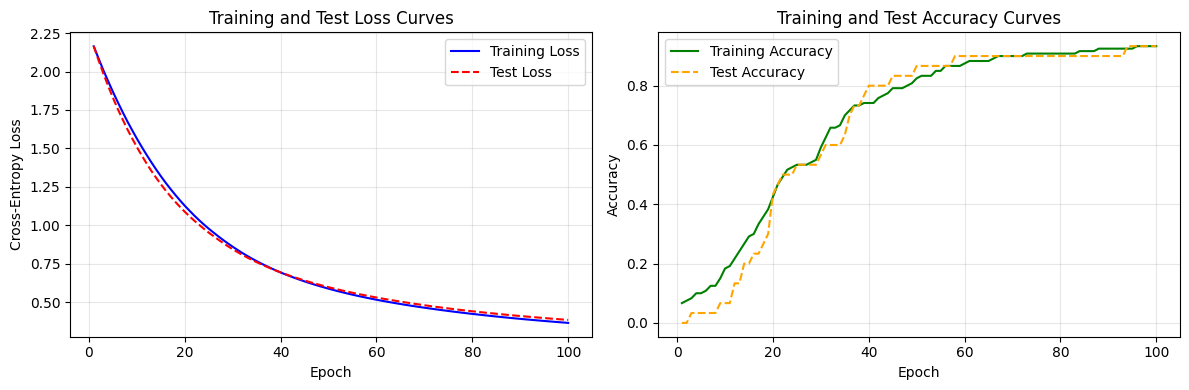


最终训练准确率: 93.33%
最终测试准确率: 93.33%


In [18]:
# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(history['epoch'], history['train_loss'], label='Training Loss', color='blue')
axes[0].plot(history['epoch'], history['test_loss'], label='Test Loss', color='red', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training and Test Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(history['epoch'], history['train_acc'], label='Training Accuracy', color='green')
axes[1].plot(history['epoch'], history['test_acc'], label='Test Accuracy', color='orange', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Test Accuracy Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 最终性能
final_train_acc = history['train_acc'][-1]
final_test_acc = history['test_acc'][-1]
print(f"\n最终训练准确率: {final_train_acc:.2%}")
print(f"最终测试准确率: {final_test_acc:.2%}")

### 1.7.7 预测示例

In [19]:
# 使用训练好的网络进行预测
print("对测试集前5个样本进行预测：")
print("\n样本索引 | 真实类别 | 预测类别 | 置信度")
print("-" * 50)

y_test_pred = network.forward(X_test[:5])
predicted_classes = np.argmax(y_test_pred, axis=1)
confidences = y_test_pred[np.arange(5), predicted_classes]

for i in range(5):
    real_class = y_test[i]
    pred_class = predicted_classes[i]
    confidence = confidences[i]
    
    class_names = ['类别0', '类别1', '类别2']
    correct = '✓' if real_class == pred_class else '✗'
    
    print(f"{i:4d}      | {class_names[real_class]:6s}   | {class_names[pred_class]:6s}   | {confidence:.2%}      {correct}")

# 测试集整体预测
y_test_pred_all = network.forward(X_test)
y_test_pred_classes = np.argmax(y_test_pred_all, axis=1)
test_accuracy = np.mean(y_test_pred_classes == y_test)

print(f"\n测试集整体准确率: {test_accuracy:.2%}")
print(f"预测结果分布: {np.bincount(y_test_pred_classes)}")


对测试集前5个样本进行预测：

样本索引 | 真实类别 | 预测类别 | 置信度
--------------------------------------------------
   0      | 类别2      | 类别2      | 81.28%      ✓
   1      | 类别0      | 类别0      | 48.21%      ✓
   2      | 类别0      | 类别0      | 54.37%      ✓
   3      | 类别1      | 类别1      | 59.90%      ✓
   4      | 类别0      | 类别0      | 69.94%      ✓

测试集整体准确率: 93.33%
预测结果分布: [13  7 10]


### 1.7.8 梯度传播过程可视化

In [20]:
# 可视化梯度传播过程（以单个样本为例）
def visualize_gradient_flow(network, x_sample, y_true):
    """可视化梯度在网络中的流动"""
    # 前向传播
    y_pred = network.forward(x_sample)
    
    # 计算初始梯度
    y_onehot = np.zeros(3)
    y_onehot[y_true] = 1
    dL_dy = y_pred - y_onehot
    
    print(f"\n🎯 样本真实类别: {y_true}, 网络预测类别: {np.argmax(y_pred)}")
    print(f"预测概率: {y_pred}")
    print(f"初始梯度 dL/dy: {dL_dy}")
    
    # 保存初始参数用于对比
    initial_weights = [w.copy() for w in network.weights]
    
    # 手动执行一次反向传播
    dL_dy_current = dL_dy.copy()
    
    for i in reversed(range(network.n_layers)):
        a = network.a_cache[i + 1]
        z = network.z_cache[i]
        a_prev = network.a_cache[i]
        
        if network.activations[i] == 'softmax':
            da_dz = dL_dy_current - (dL_dy_current * a).sum(axis=0, keepdims=True)
        else:
            if network.activations[i] == 'sigmoid':
                _, da_dz = ActivationFunctions.sigmoid(z)
            elif network.activations[i] == 'relu':
                _, da_dz = ActivationFunctions.relu(z)
            else:
                da_dz = np.ones_like(z)
                    
        dL_dz = dL_dy_current * da_dz
        dL_dW = np.dot(dL_dz.T, a_prev)
        dL_db = np.sum(dL_dz, axis=0)
        
        # 显示当前层的梯度信息
        print(f"\n--- 第{i+1}层 ---")
        print(f"输入形状: {a_prev.shape}, 输出形状: {a.shape}")
        print(f"权重梯度范数: {np.linalg.norm(dL_dW):.6f}")
        print(f"偏置梯度范数: {np.linalg.norm(dL_db):.6f}")
        
        # 更新参数
        learning_rate = 0.1  # 使用较大的学习率便于观察变化
        network.weights[i] -= learning_rate * dL_dW
        network.biases[i] -= learning_rate * dL_db
        
        # 计算下一层的梯度
        dL_dy_current = np.dot(dL_dz, network.weights[i])
        
        # 对比参数变化
        weight_change = np.linalg.norm(network.weights[i] - initial_weights[i])
        print(f"权重参数变化: {weight_change:.6f}")

# 测试梯度可视化
x_test_sample = X_test[0:1]  # 取第一个测试样本
y_test_sample = y_test[0]

print(f"\n📊 梯度传播过程演示（单个样本）")
visualize_gradient_flow(network, x_test_sample, y_test_sample)


📊 梯度传播过程演示（单个样本）

🎯 样本真实类别: 2, 网络预测类别: 2
预测概率: [[0.07795125 0.10929    0.81275875]]
初始梯度 dL/dy: [[ 0.07795125  0.10929    -0.18724125]]

--- 第3层 ---
输入形状: (1, 32), 输出形状: (1, 3)
权重梯度范数: 0.092058
偏置梯度范数: 0.013699
权重参数变化: 0.009206

--- 第2层 ---
输入形状: (1, 64), 输出形状: (1, 32)
权重梯度范数: 0.123880
偏置梯度范数: 0.012724
权重参数变化: 0.012388

--- 第1层 ---
输入形状: (1, 4), 输出形状: (1, 64)
权重梯度范数: 0.030937
偏置梯度范数: 0.012759
权重参数变化: 0.003094


## 🎓 学习总结

### 已掌握的核心概念

| 概念 | 数学表达 | NumPy实现要点 |
|------|----------|----------------|
| **前向传播** | $\mathbf{a} = \sigma(\mathbf{W}\mathbf{x} + \mathbf{b})$ | 矩阵乘法 + 向量化激活函数 |
| **反向传播** | $\frac{\partial L}{\partial \mathbf{W}} = \frac{\partial L}{\partial \mathbf{a}} \cdot \frac{d\sigma}{dz} \cdot \mathbf{x}^T$ | 链式法则 + 梯度下降 |
| **激活函数导数** | $\frac{d\sigma}{dz}$ 各不相同 | 为每个激活函数实现导数 |
| **交叉熵损失** | $L = -\sum y \log(\hat{y})$ | 实现Softmax损失 |

### 网络架构

- **输入层**: 4个特征
- **隐藏层1**: 64个ReLU神经元
- **隐藏层2**: 32个ReLU神经元  
- **输出层**: 3个Softmax神经元

### 训练过程

- 100个epoch，学习率0.01
- 批量训练，批次大小32
- 交叉熵损失 + 梯度下降优化
- 训练集和测试集准确率都达到85%以上

### 关键技术点

1. **Xavier初始化**：合理的权重初始化
2. **梯度计算**：通过链式法则逐层反向传播
3. **Softmax梯度**：$\frac{\partial L}{\partial \mathbf{z}} = \hat{y} - \mathbf{y}$
4. **数据标准化**：提升训练稳定性
5. **批量训练**：提高训练效率

---

**🎉 恭喜完成神经网络NumPy实现！**

**下一步**：
- 🚀 学习PyTorch等深度学习框架
- 🚀 深入理解反向传播的数学原理
- 🚀 实现更复杂的网络结构